<a href="https://colab.research.google.com/github/siddhiofficial/Siddhi/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Siddhi J Salunkhe
#23BDS0243
#EDA Course Project: Phase 1 & Phase 2

#Phase 1

#Importing and Loading dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving NaturalGas.csv to NaturalGas.csv


#Reading the dataset

In [2]:
import pandas as pd

df = pd.read_csv("NaturalGas.csv")
df.head()

,rownames,state,statecode,year,consumption,price,eprice,oprice,lprice,heating,income
0,1,NY,35,1967,313656,1.42,2.98,7.40,1.47,6262,10903.75
1,2,NY,35,1968,319282,1.38,2.91,7.77,1.42,6125,11370.02
2,3,NY,35,1969,331326,1.37,2.84,7.96,1.38,6040,11578.68
3,4,NY,35,1970,346533,1.40,2.87,8.33,1.37,6085,11586.77
4,5,NY,35,1971,352085,1.50,3.07,8.80,1.40,5907,11657.42


#Basic Statistical Analysis

In [3]:
df.info()

df.describe(include='all')

df.shape

df.columns

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     138 non-null    int64  
 1   state        138 non-null    object 
 2   statecode    138 non-null    int64  
 3   year         138 non-null    int64  
 4   consumption  138 non-null    int64  
 5   price        138 non-null    float64
 6   eprice       138 non-null    float64
 7   oprice       138 non-null    float64
 8   lprice       138 non-null    float64
 9   heating      138 non-null    int64  
 10  income       138 non-null    float64
dtypes: float64(5), int64(5), object(1)
memory usage: 12.0+ KB


,0
rownames,int64
state,object
statecode,int64
year,int64
consumption,int64
price,float64
eprice,float64
oprice,float64
lprice,float64
heating,int64


#Handling missing data

In [4]:
df.isnull().sum()

#remove columns with >70% missing
(df.isnull().sum()/len(df))*100

#fill numerical values
df.fillna(df.mean(numeric_only=True), inplace=True)

#fill categorical values
df.fillna(df.mode().iloc[0], inplace=True)

#Data cleaning

In [5]:
# Checking for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Removing duplicates
df.drop_duplicates(inplace=True)

# Verifying data types
print(df.dtypes)

Duplicate Rows: 0
rownames         int64
state           object
statecode        int64
year             int64
consumption      int64
price          float64
eprice         float64
oprice         float64
lprice         float64
heating          int64
income         float64
dtype: object


#Data Transformation

In [6]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

#Log transform income
df["log_income"] = np.log(df["income"])

#Normalizing Consumption
scaler = MinMaxScaler()
df["consumption_scaled"] = scaler.fit_transform(df[["consumption"]])

#displaying new data
df[["income", "log_income", "consumption", "consumption_scaled"]].head()

,income,log_income,consumption,consumption_scaled
0,10903.75,9.296862,313656,0.484545
1,11370.02,9.338735,319282,0.493506
2,11578.68,9.356921,331326,0.512688
3,11586.77,9.357619,346533,0.536909
4,11657.42,9.363698,352085,0.545752


#Univariate Analysis(Minimum 3 plots)

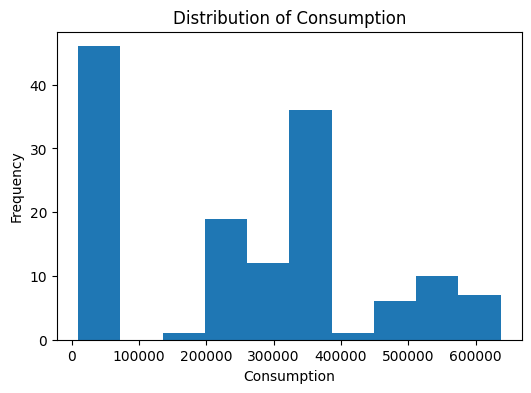

In [7]:
#Distribution of consumption
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["consumption"], bins=10)
plt.title("Distribution of Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")
plt.show()

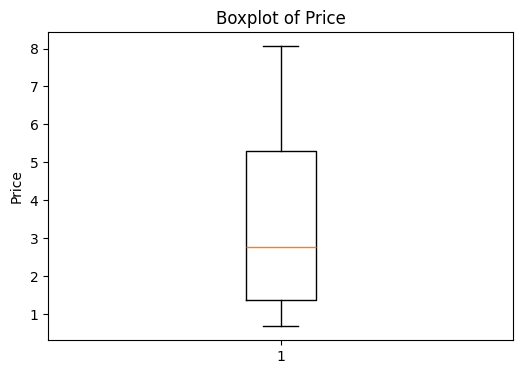

In [8]:
#Price distribution
plt.figure(figsize=(6,4))
plt.boxplot(df["price"])
plt.title("Boxplot of Price")
plt.ylabel("Price")
plt.show()

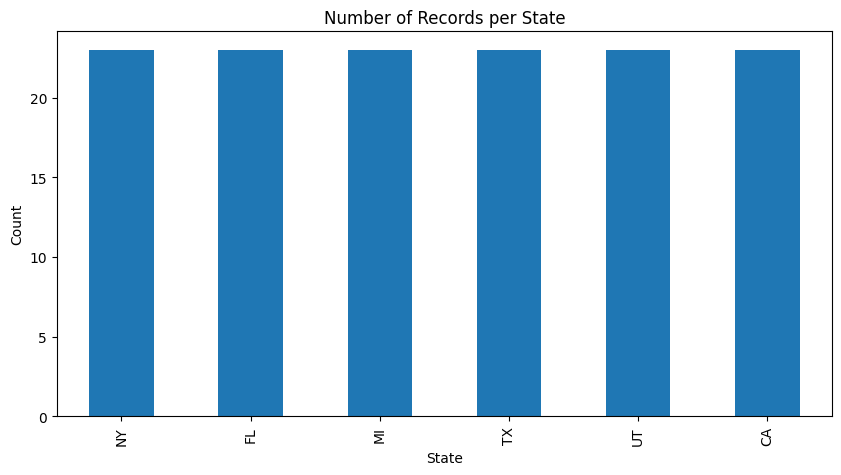

In [9]:
#States count
df["state"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Number of Records per State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

#Bivariate Analysis(Minimum 3 plots)

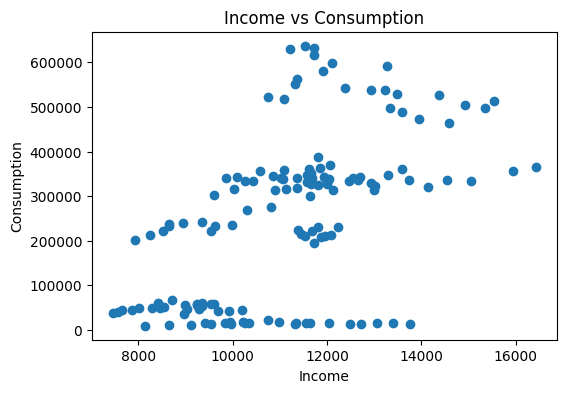

In [10]:
#Income Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["income"], df["consumption"])

plt.title("Income vs Consumption")
plt.xlabel("Income")
plt.ylabel("Consumption")

plt.show()

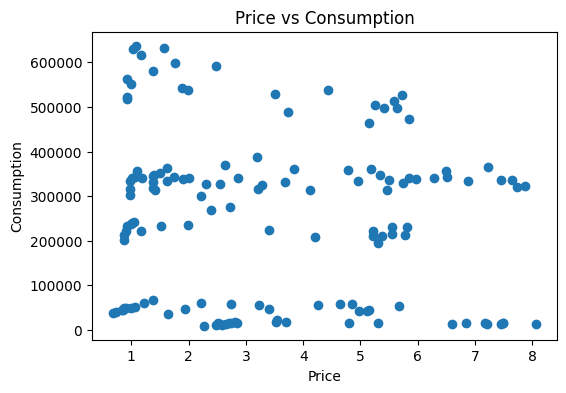

In [11]:
#Price Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["price"], df["consumption"])

plt.title("Price vs Consumption")
plt.xlabel("Price")
plt.ylabel("Consumption")

plt.show()

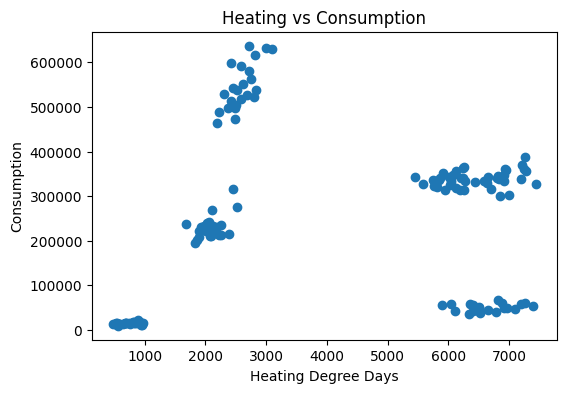

In [12]:
#Heating Vs Consumption
plt.figure(figsize=(6,4))

plt.scatter(df["heating"], df["consumption"])

plt.title("Heating vs Consumption")
plt.xlabel("Heating Degree Days")
plt.ylabel("Consumption")

plt.show()

#Multivariate Analysis(Minimum 3 plots)

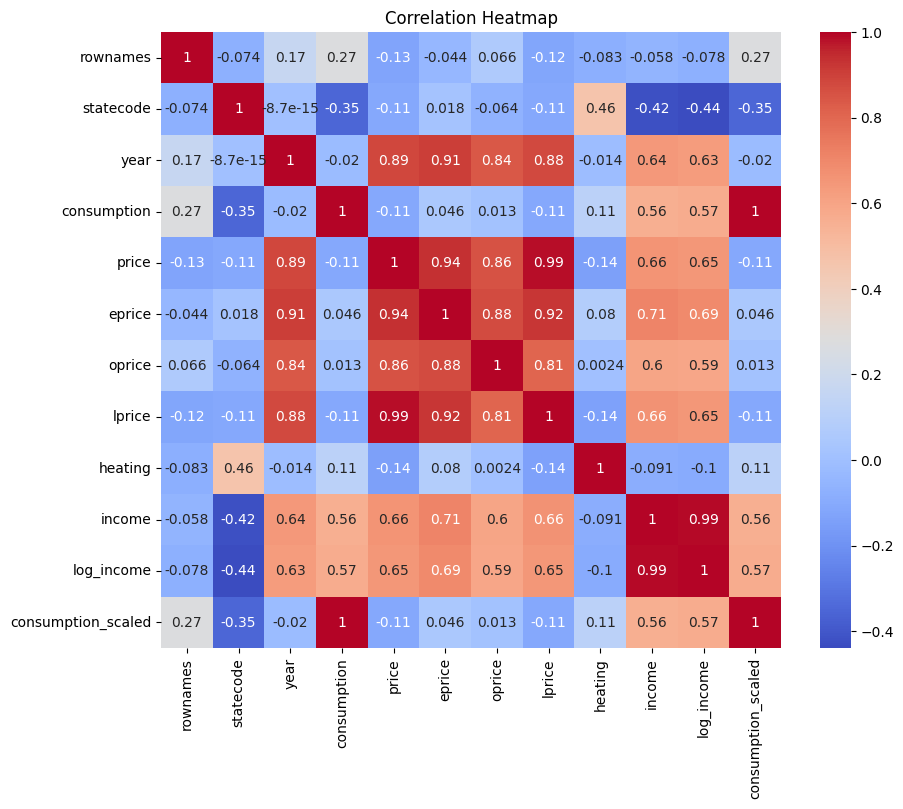

In [13]:
#Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

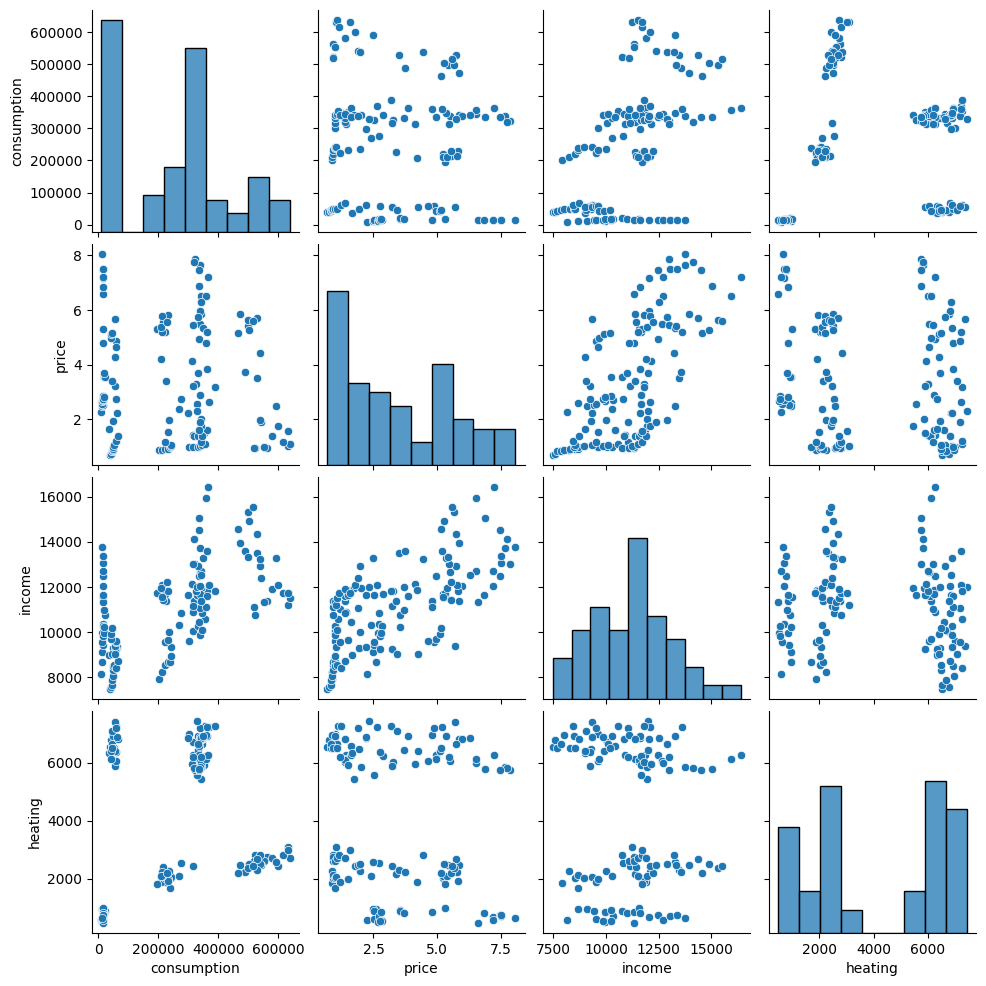

In [14]:
#Pair plot
sns.pairplot(
    df[
        [
            "consumption",
            "price",
            "income",
            "heating"
        ]
    ]
)

plt.show()

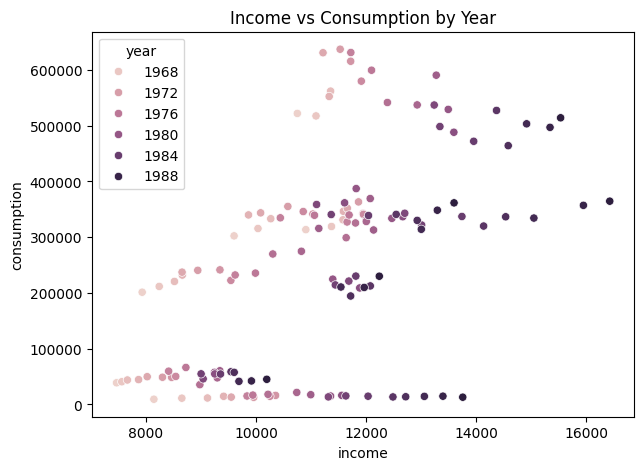

In [15]:
#Income Vs Consumption(colored by year)
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="income",
    y="consumption",
    hue="year"
)

plt.title("Income vs Consumption by Year")

plt.show()

#Phase 2
#1D Statistical Analysis
#Mean

In [17]:
mean_values = df["income"].mean()

print("Mean:")
display(mean_values)

Mean:


np.float64(11193.235652173913)

#Median

In [18]:
median_values = df["income"].median()

print("Median:")
display(median_values)

Median:


11367.46

#Mode

In [19]:
mode_values = df["eprice"].mode().iloc[0]

print("Mode:")
display(mode_values)

Mode:


np.float64(2.23)

#Variance

In [20]:
variance_values = df["eprice"].var()

print("Variance:")
display(variance_values)

Variance:


6.64535445361261

#Standard Deviation

In [21]:
std_values = df["eprice"].std()

print("Standard Deviation:")
display(std_values)

Standard Deviation:


2.577858501472222

#Minimum and Maximum

In [22]:
min_values = df["income"].min()
max_values = df["income"].max()

print("Minimum:")
display(min_values)

print("\nMaximum:")
display(max_values)

Minimum:


7465.34


Maximum:


16425.33

#Range

In [23]:
range_values = df["income"].max() - df["income"].min()

print("Range:")
display(range_values)

Range:


8959.990000000002

#Skewness

In [24]:
skewness = df["income"].skew()

print("Skewness:")
display(skewness)

Skewness:


np.float64(0.2441020659812335)

#Kurtosis

In [25]:
kurtosis = df["income"].kurtosis()

print("Kurtosis:")
display(kurtosis)

Kurtosis:


np.float64(-0.22781705705239386)

#Histogram - Consumption

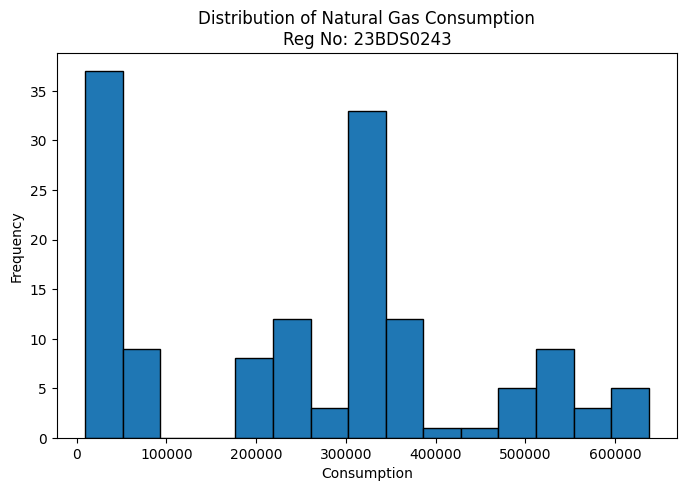

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df['consumption'], bins=15, edgecolor='black')

plt.title("Distribution of Natural Gas Consumption\nReg No: 23BDS0243")
plt.xlabel("Consumption")
plt.ylabel("Frequency")

plt.show()

#Histogram - Price

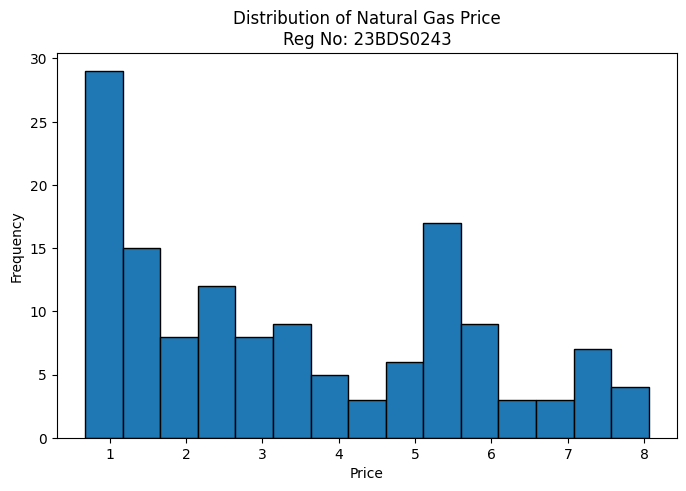

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=15, edgecolor='black')

plt.title("Distribution of Natural Gas Price\nReg No: 23BDS0243")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

#Boxplot

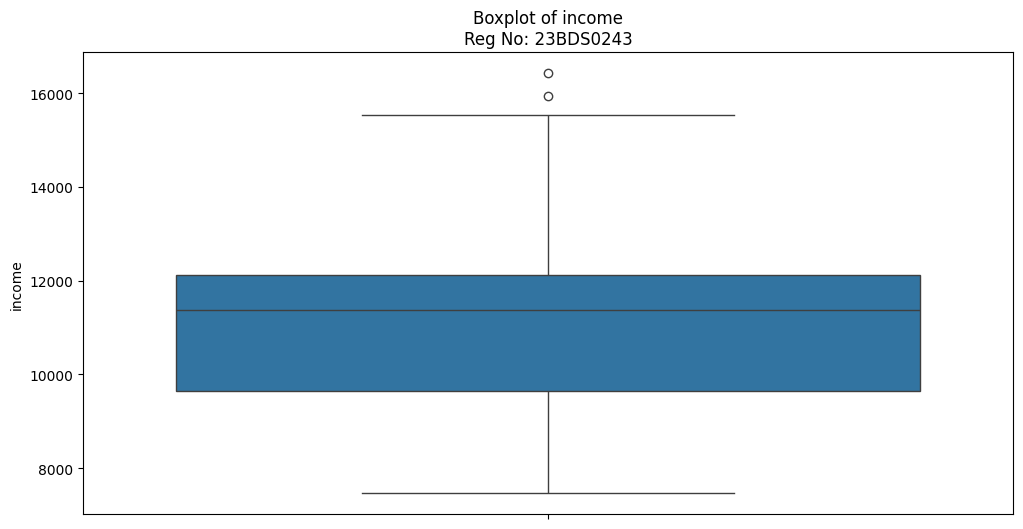

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df["income"])

plt.title("Boxplot of income\nReg No: 23BDS0243")
plt.xticks(rotation=45)

plt.show()

#Frequency Distribution and Bar chart

In [30]:
state_frequency = df['state'].value_counts()

print("State Frequency Distribution:")
display(state_frequency)

State Frequency Distribution:


,count
state,
NY,23
FL,23
MI,23
TX,23
UT,23
CA,23


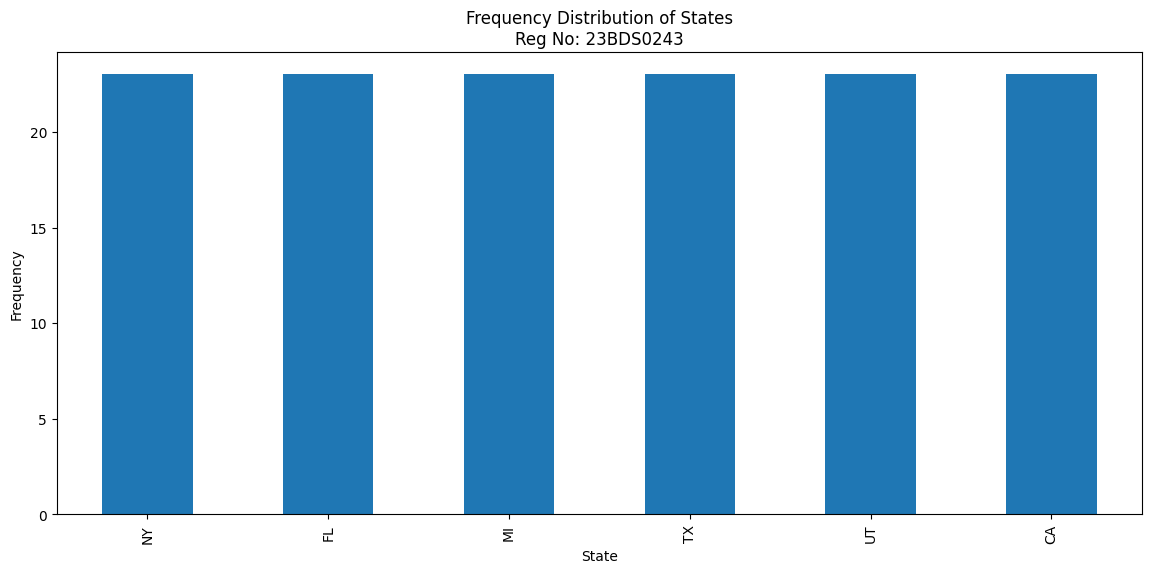

In [31]:
plt.figure(figsize=(14,6))

df['state'].value_counts().plot(kind='bar')

plt.title("Frequency Distribution of States\nReg No: 23BDS0243")
plt.xlabel("State")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

#2D Statistical Analysis
#Correlation Matrix


In [37]:
correlation = df["income"].corr(df["consumption"])

print("Correlation:", correlation)

Correlation: 0.558558951233098


#Heatmap

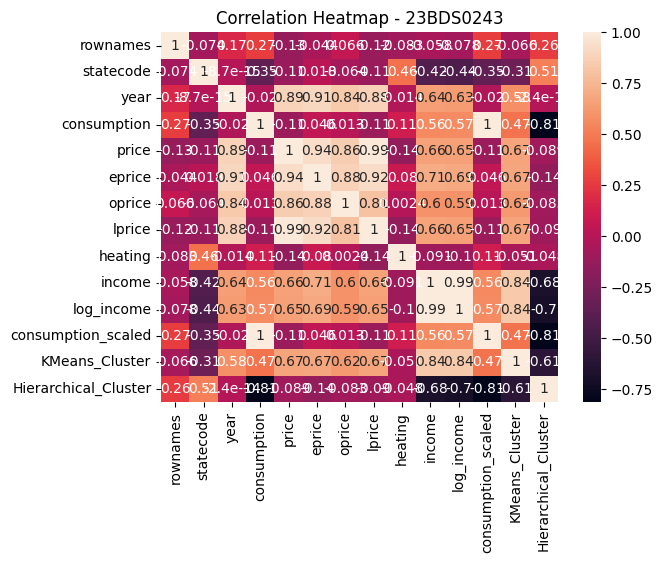

In [51]:
correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap - 23BDS0243")
plt.show()

#Consumption Vs Price Correlation

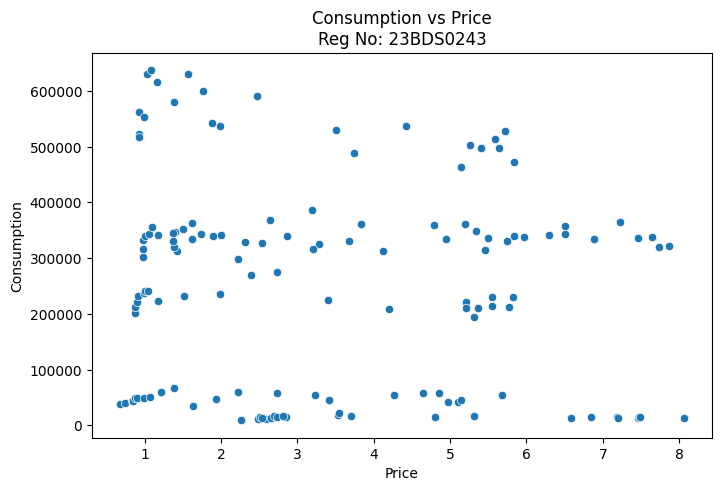

Correlation between Price and Consumption: -0.10954080343672169


In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='price',
    y='consumption'
)

plt.title("Consumption vs Price\nReg No: 23BDS0243")
plt.xlabel("Price")
plt.ylabel("Consumption")

plt.show()

correlation = df['price'].corr(df['consumption'])
print("Correlation between Price and Consumption:", correlation)

#Consumption Vs Income

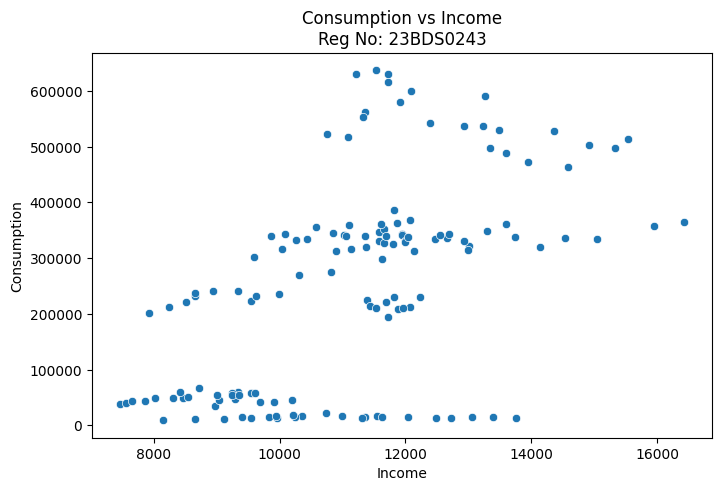

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='income',
    y='consumption'
)

plt.title("Consumption vs Income\nReg No: 23BDS0243")
plt.xlabel("Income")
plt.ylabel("Consumption")

plt.show()

#Consumption Vs heating

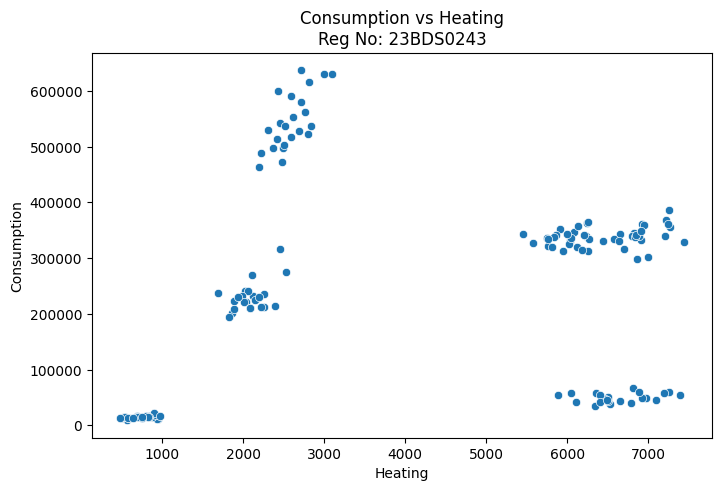

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='heating',
    y='consumption'
)

plt.title("Consumption vs Heating\nReg No: 23BDS0243")
plt.xlabel("Heating")
plt.ylabel("Consumption")

plt.show()

#Regression Analysis
#Price Vs Consumption

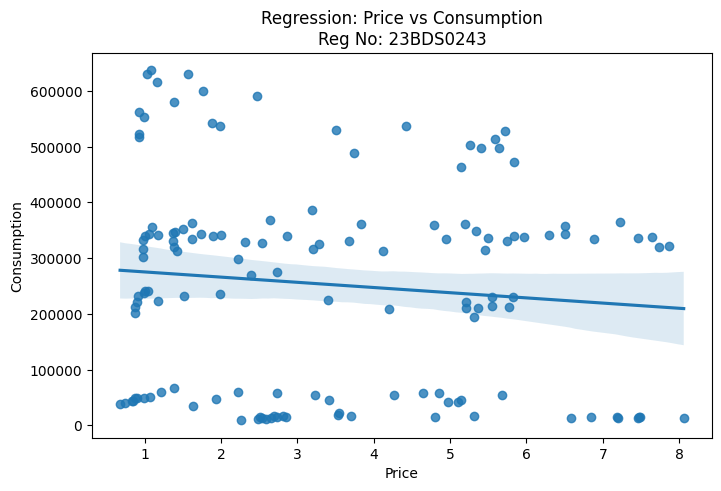

In [41]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='price',
    y='consumption'
)

plt.title("Regression: Price vs Consumption\nReg No: 23BDS0243")
plt.xlabel("Price")
plt.ylabel("Consumption")

plt.show()

#Pearson Correlation Test

In [45]:
from scipy import stats

correlation, p_value = stats.pearsonr(
    df['price'],
    df['consumption']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("The relationship is statistically significant.")
else:
    print("The relationship is not statistically significant.")

Pearson Correlation: -0.10954080343672165
P-value: 0.20091088479038385
The relationship is not statistically significant.


#3D Statistical Analysis - using price, consumption,income
#3D Scatter Plot

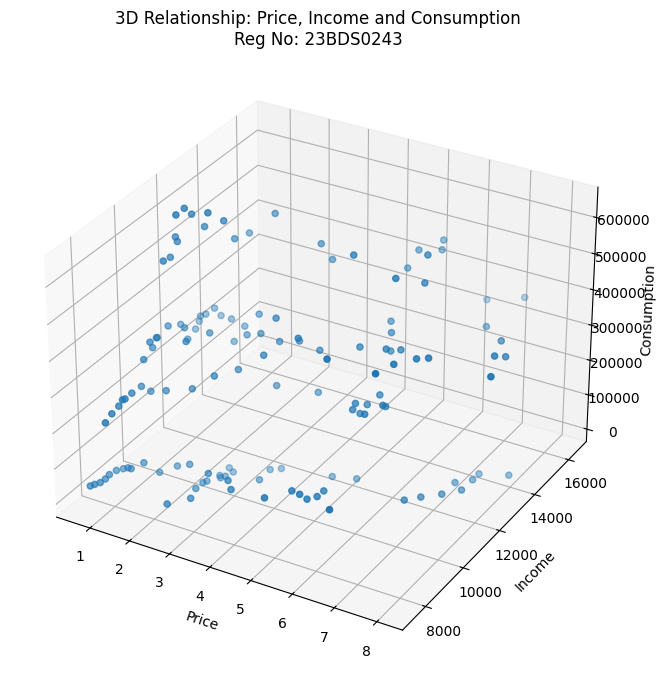

In [46]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['price'],
    df['income'],
    df['consumption']
)

ax.set_xlabel("Price")
ax.set_ylabel("Income")
ax.set_zlabel("Consumption")

ax.set_title("3D Relationship: Price, Income and Consumption\nReg No: 23BDS0243")

plt.show()

#3D Correlation Analysis

In [47]:
three_variables = df[['consumption', 'price', 'income']]

print("3D Variable Correlation:")
display(three_variables.corr())

3D Variable Correlation:


,consumption,price,income
consumption,1.000000,-0.109541,0.558559
price,-0.109541,1.000000,0.658469
income,0.558559,0.658469,1.000000


#K Means Clustering

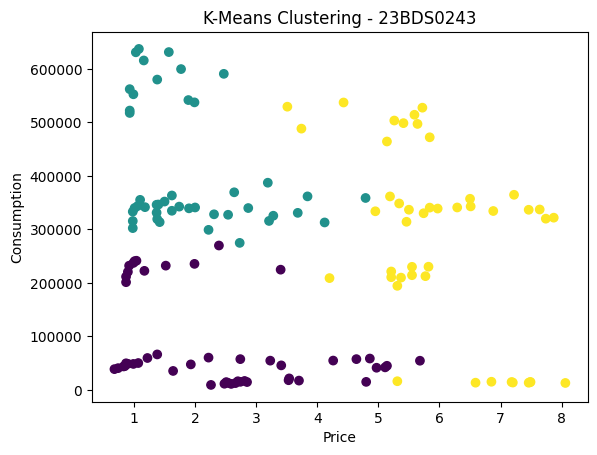

  state  KMeans_Cluster
0    NY               1
1    NY               1
2    NY               1
3    NY               1
4    NY               1


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['consumption', 'price', 'income', 'heating']]
X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

plt.scatter(df['price'], df['consumption'], c=df['KMeans_Cluster'])
plt.title("K-Means Clustering - 23BDS0243")
plt.xlabel("Price")
plt.ylabel("Consumption")
plt.show()

print(df[['state', 'KMeans_Cluster']].head())

#Hierarchial Clustering

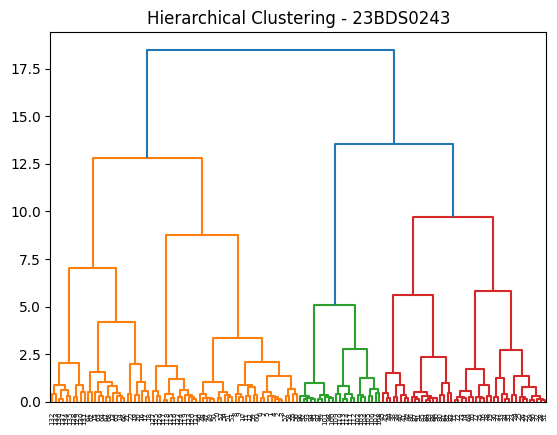

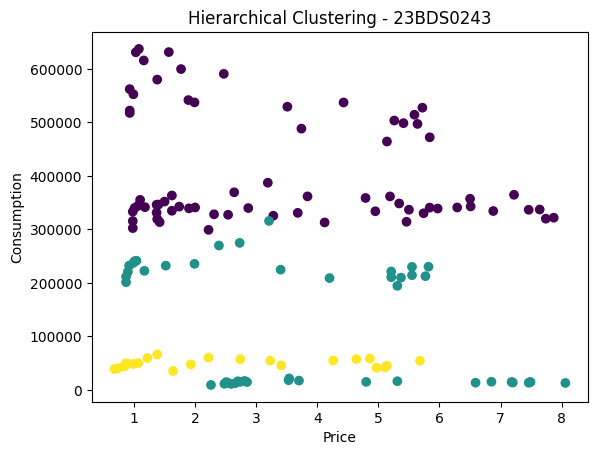

  state  Hierarchical_Cluster
0    NY                     0
1    NY                     0
2    NY                     0
3    NY                     0
4    NY                     0


In [49]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X = df[['consumption', 'price', 'income', 'heating']]
X = StandardScaler().fit_transform(X)

# Dendrogram
dendrogram(linkage(X, method='ward'))
plt.title("Hierarchical Clustering - 23BDS0243")
plt.show()

# Clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X)

plt.scatter(df['price'], df['consumption'], c=df['Hierarchical_Cluster'])
plt.title("Hierarchical Clustering - 23BDS0243")
plt.xlabel("Price")
plt.ylabel("Consumption")
plt.show()

print(df[['state', 'Hierarchical_Cluster']].head())